/var/folders/h2/pwk44qps4vg3bngldbgd397w0000gn/T/ipykernel_22005/1173848511.py:19: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  count_b = np.zeros(256,np.float)
/var/folders/h2/pwk44qps4vg3bngldbgd397w0000gn/T/ipykernel_22005/1173848511.py:20: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  count_g = np.zeros(256,np.float)
/var/folders/h2/

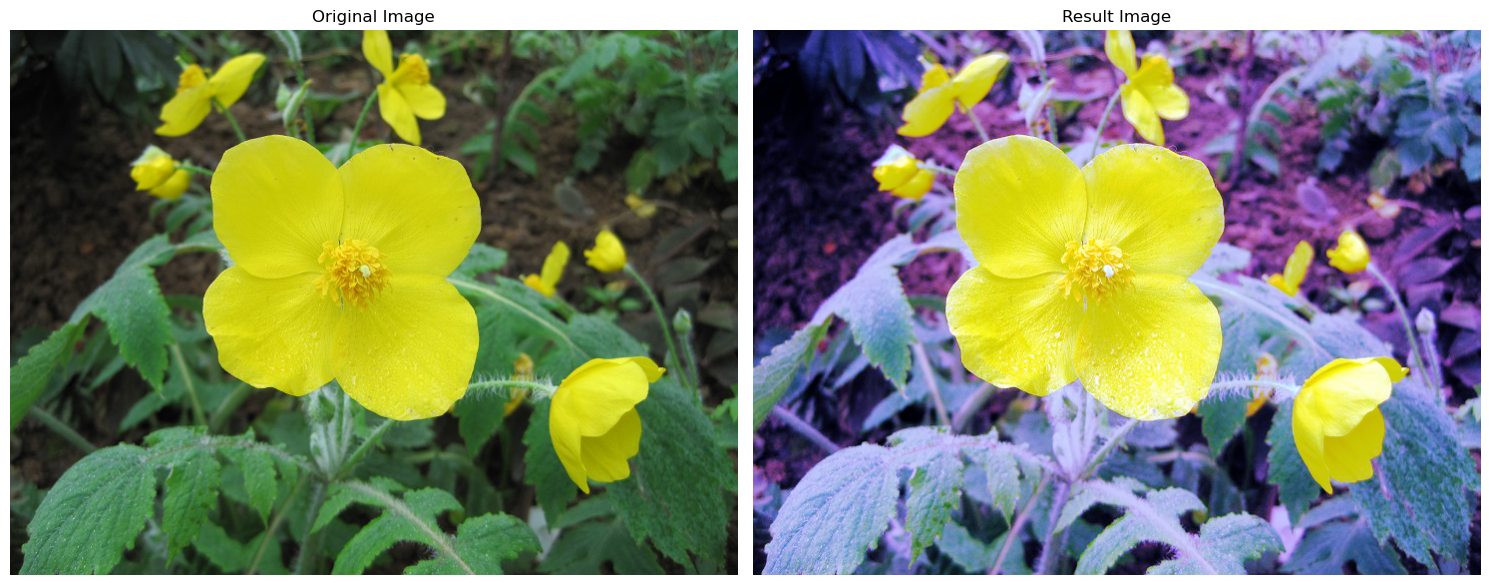

In [1]:
# 本质：统计每个像素灰度 出现的概率 0-255 p
# 累计概率 
# 1 0.2  0.2
# 2 0.3  0.5
# 3 0.1  0.6
# 256 
# 100 0.5 255*0.5 = new 
# 1 统计每个颜色出现的概率 2 累计概率 1 3 0-255 255*p
# 4 pixel 
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread('/Users/xh/workspaces/jupyter/opencv-example/2入门/opencv入门/image0.JPG', 1)

imgInfo = img.shape
height = imgInfo[0]
width = imgInfo[1]

count_b = np.zeros(256,np.float)
count_g = np.zeros(256,np.float)
count_r = np.zeros(256,np.float)
for i in range(0,height):
    for j in range(0,width):
        (b,g,r) = img[i,j]
        index_b = int(b)
        index_g = int(g)
        index_r = int(r)
        count_b[index_b] = count_b[index_b]+1
        count_g[index_g] = count_g[index_g]+1
        count_r[index_r] = count_r[index_r]+1
for i in range(0,255):
    count_b[i] = count_b[i]/(height*width)
    count_g[i] = count_g[i]/(height*width)
    count_r[i] = count_r[i]/(height*width)
#计算累计概率
sum_b = float(0)
sum_g = float(0)
sum_r = float(0)
for i in range(0,256):
    sum_b = sum_b+count_b[i]
    sum_g = sum_g+count_g[i]
    sum_r = sum_r+count_r[i]
    count_b[i] = sum_b
    count_g[i] = sum_g
    count_r[i] = sum_r
#print(count)
# 计算映射表
map_b = np.zeros(256,np.uint16)
map_g = np.zeros(256,np.uint16)
map_r = np.zeros(256,np.uint16)
for i in range(0,256):
    map_b[i] = np.uint16(count_b[i]*255)
    map_g[i] = np.uint16(count_g[i]*255)
    map_r[i] = np.uint16(count_r[i]*255)
# 映射
dst = np.zeros((height,width,3),np.uint8)
for i in range(0,height):
    for j in range(0,width):
        (b,g,r) = img[i,j]
        b = map_b[b]
        g = map_g[g]
        r = map_r[r]
        dst[i,j] = (b,g,r)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 8))
# 原灰度图
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # ✅ 指定灰度颜色映射
axes[0].set_title('Original Image')
axes[0].axis('off')

# 均衡化后的图像
axes[1].imshow(cv2.cvtColor(dst, cv2.COLOR_BGR2RGB))  # ✅ 指定灰度颜色映射
axes[1].set_title('Result Image')
axes[1].axis('off')

plt.tight_layout()
plt.show()
